In [1]:
%matplotlib inline
# !pip install deeptrack deeplay # Uncomment if running on colab/kaggle.

<!--<badge>--><a href="https://colab.research.google.com/github/softmatterlab/DeepTrack-2.0/blob/develop/2-examples/DTEx231A_LodeSTAR_autotracker_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->

In [ ]:
import deeptrack as dt
import deeplay as dl
import matplotlib.pyplot as plt
import numpy as np
import torch

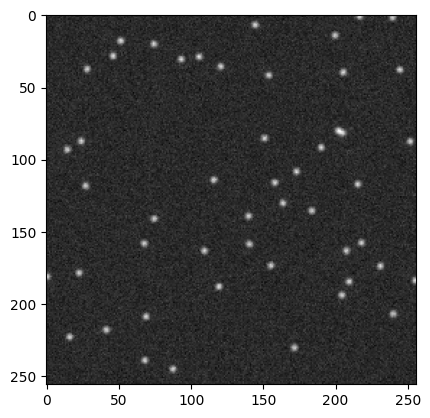

In [3]:
data = np.load("assets/data.npy")
data = (data - np.min(data)) / np.ptp(data)

plt.imshow(data[0], cmap="gray")
plt.show()

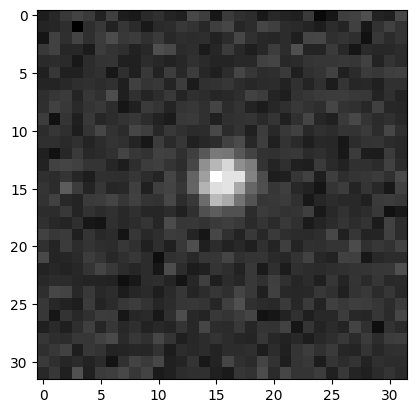

In [4]:
crop = data[0, 100:132, 100:132]
plt.imshow(crop, cmap="gray")

In [5]:
training_data = dt.Value(crop)

In [6]:
lodestar = dl.LodeSTAR(
    n_transforms=4,
    optimizer=dl.Adam(lr=1e-3)
).build()

dataset = dt.pytorch.Dataset(
    training_data,
    length=128,
)

dataloader = dl.DataLoader(
    dataset=dataset,
    batch_size=4
)
lodestar_trainer = dl.Trainer(accelerator="auto", max_epochs=50)
lodestar_trainer.fit(lodestar, dataloader)

c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:477: The total number of parameters detected may be inaccurate because the model contains an instanc

Training: |          | 0/? [00:00<?, ?it/s]

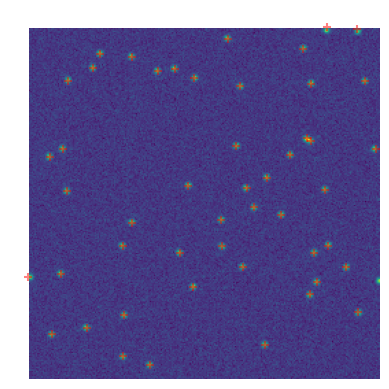

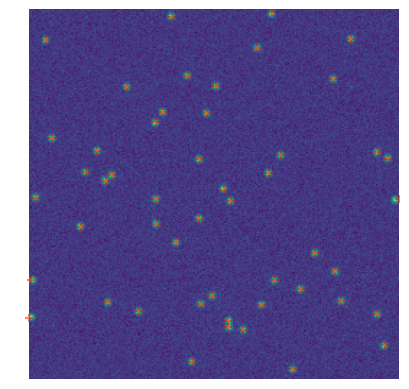

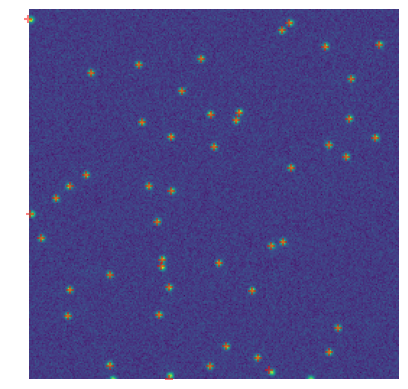

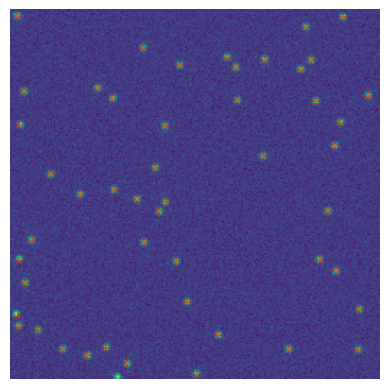

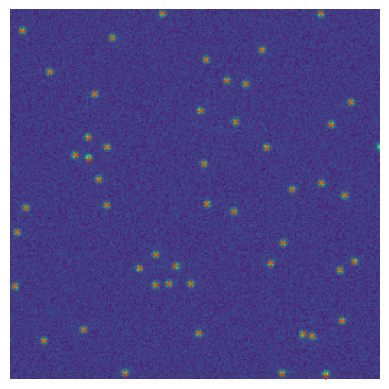

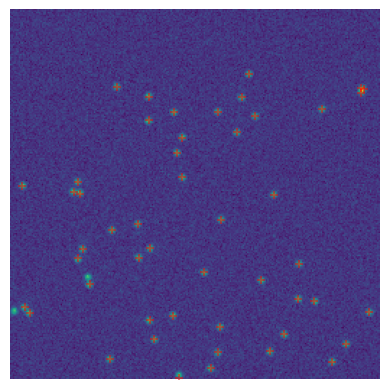

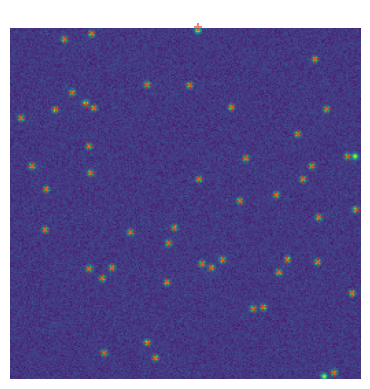

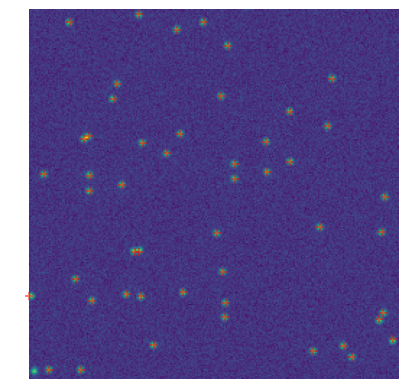

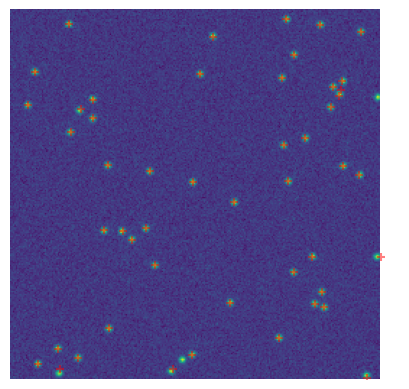

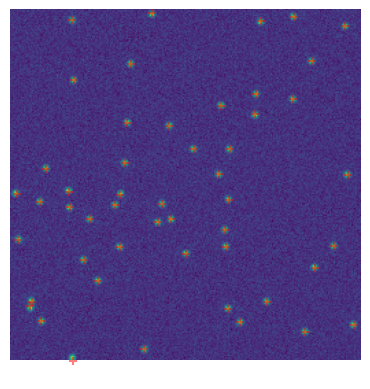

In [8]:
alpha = 0.5
beta = 1-alpha
cutoff = 0.9

data_tensor = torch.from_numpy(data).to(torch.float32).moveaxis(-1, 1)

all_detections = lodestar.detect(
    data_tensor,
    alpha=alpha,
    beta=beta,
    cutoff=cutoff,
    mode="quantile"
)

for frame, frame_detections in zip(data_tensor, all_detections):
    plt.imshow(frame.squeeze(0).detach().cpu())
    plt.scatter(frame_detections[:,1 ], frame_detections[:, 0], marker="+", c="r", alpha=0.5)
    plt.axis("off")
    plt.show()